# 04 · ADN del Entrenador — el estilo de cualquier técnico de la Liga MX, frente a la liga

**El producto.** Una metodología que responde, con el mismo lenguaje para cualquier técnico:
1. **¿Cómo juega?** Su ADN: 8 rasgos de juego ubicados frente a todos los técnicos de la Liga MX.
2. **¿Es consistente o cambia según el contexto?** Local o visita, rival fuerte o débil, torneo a torneo.
3. **¿A quién se parece y qué tanto encaja con la identidad del América?** (Índice de Encaje.)
4. **¿Lo reconoce el ADN en partidos que nunca vio?** (Validación con el cambio a Almada.)

**Para qué le sirve al club:**
- elegir técnico (candidatos frente a la identidad del club);
- dar seguimiento al técnico actual (¿mantiene su idea?);
- preparar partidos (el ADN del técnico rival).

**Datos y partición oficial:**
- `team-match-stats` de **toda la liga**: 1,789 partidos y 106 entrenadores.
- **Entrenamiento** = ventana oficial del hackathon (Apertura 2021 – Clausura 2025).
- **Validación** = Apertura 2025.
- **Prueba** = 2026, que incluye la llegada de Almada al América.
- Todo lo que se "aprende" (medias, escalas, efectos del rival, clasificador) se ajusta **solo con la ventana oficial**.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import coach_profile as C, coach_viz as V, business as B, eda
from src.pipeline.config import GOLD
from src.evaluation import ANALYSIS

pd.set_option("display.max_columns", 30, "display.width", 250, "display.float_format", lambda v: f"{v:,.2f}")
FIG = ROOT / "reports" / "figures" / "coach"; FIG.mkdir(parents=True, exist_ok=True)
ANALYSIS.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=140, bbox_inches="tight"); plt.show()

def keep(df, name):
    out = df.copy(); out.columns = [str(c) for c in out.columns]
    out.to_parquet(ANALYSIS / f"coach_{name}.parquet"); display(df)

tml = C.load_league()
ma = C.build_match_axes(tml)
AM = C.TEAM
print(f"{tml.match_id.nunique():,} partidos de liga · {tml.manager.replace('', np.nan).nunique()} entrenadores · "
      f"train {(tml.split=='train').sum():,} · val {(tml.split=='val').sum():,} · test {(tml.split=='test').sum():,} filas equipo-partido")

1,789 partidos de liga · 106 entrenadores · train 2,728 · val 340 · test 510 filas equipo-partido


## 1. Los 8 rasgos del ADN

Cada rasgo combina 2–4 métricas de StatsBomb. Cada métrica se estandariza con la liga y el rasgo es su promedio, con el
signo orientado para que **más = más de ese rasgo**: por ejemplo, un PPDA bajo cuenta como *más* presión.

In [2]:
axes_tab = pd.DataFrame([(a, ", ".join(("−" if s < 0 else "") + m for m, s in mets.items()), txt)
                         for a, (mets, txt) in C.PROFILE_AXES.items()],
                        columns=["rasgo", "métricas (− = invertida)", "qué significa"]).set_index("rasgo")
keep(axes_tab, "axes")

,métricas (− = invertida),qué significa
rasgo,,
Control del balón,"possession, pass_completion, time_in_control",Cuánto tiempo tiene el balón y qué tan seguro ...
Verticalidad,"directness, pace_towards_goal, avg_team_posses...",Qué tan rápido y directo va hacia la portería ...
Llegada al área,"deep_progressions, deep_completions, passes_in...",Cuántas veces pisa el último tercio y el área ...
Presión alta,"−ppda, fhalf_pressures_ratio, defensive_distan...",Qué tan arriba y qué tan intenso intenta recup...
Reacción tras pérdida,"counterpressures, counterpressure_regains",Cuánto presiona justo después de perder el bal...
Peligro generado,"np_xg, np_xg_per_shot, obv",Calidad y cantidad de las ocasiones que crea.
Solidez defensiva,"−np_xg_conceded, −deep_progressions_conceded, ...",Qué tan poco peligro y qué tan pocas llegadas ...
Balón parado,"sp_xg, xg_per_sp, −sp_xg_conceded","Peligro a favor en jugadas a balón parado, men..."


**Ajuste por contexto.** Un técnico de un equipo grande "tiene más balón" en parte porque enfrenta a rivales que se lo
ceden. Para medir el estilo **del técnico** y no el del calendario, a cada rasgo se le quita el efecto del rival
(un efecto fijo por equipo rival) y el de la localía, estimados con la ventana oficial. El resultado es el
**perfil ajustado**, que se usa en todo el notebook salvo que se indique lo contrario.

In [3]:
raw = ma[[f"raw__{a}" for a in C.AXES]].var().values
adj = ma[[f"adj__{a}" for a in C.AXES]].var().values
keep(pd.DataFrame({"varianza cruda": raw, "varianza ajustada": adj,
                   "% explicado por rival y localía": (1 - adj / raw) * 100}, index=C.AXES), "context_share")

,varianza cruda,varianza ajustada,% explicado por rival y localía
Control del balón,0.88,0.81,7.95
Verticalidad,0.46,0.45,1.66
Llegada al área,0.72,0.65,9.69
Presión alta,0.62,0.55,9.80
Reacción tras pérdida,0.88,0.86,2.73
Peligro generado,0.67,0.63,5.70
Solidez defensiva,0.52,0.44,15.63
Balón parado,0.58,0.55,5.17


## 2. El ADN de los técnicos del América

Percentil de cada rasgo frente a los **70 técnicos-club de la liga con 15 partidos o más en la ventana oficial**. Por
ejemplo, 90 significa que tiene más de ese rasgo que 9 de cada 10 técnicos de la liga. Solari, Ortiz y Jardine se miden
con la ventana oficial y Almada con sus partidos de 2026 en el América (datos de prueba). La banda es la incertidumbre
(IC 90 % por remuestreo de partidos).

In [4]:
ref = C.coach_profiles(ma)                                   # referencia: liga, ventana oficial, ≥15 partidos
AMC = {"Solari": "Santiago Hernán Solari Poggio", "Ortiz": "Fernando Ortiz", "Jardine": "André Soares Jardine",
       "Almada": "Jorge Guillermo Almada Álves"}
rows_am = {k: (ma.team_name == AM) & (ma.manager == v) & ((ma.split == "train") if k != "Almada" else (ma.split == "test"))
           for k, v in AMC.items()}
means = pd.DataFrame({k: ma.loc[r, [f"adj__{a}" for a in C.AXES]].mean().set_axis(C.AXES) for k, r in rows_am.items()}).T
means["partidos"] = [int(r.sum()) for r in rows_am.values()]
pct = C.to_percentile(means, ref)
cis = {}
for k, r in rows_am.items():
    ci = C.bootstrap_ci(ma, r)
    cis[k] = C.to_percentile(ci.T.rename(index={"lo": "lo", "hi": "hi"}).assign(partidos=0), ref)[C.AXES].T
keep(pct[C.AXES + ["partidos"]].round(0), "america_percentiles")

,Control del balón,Verticalidad,Llegada al área,Presión alta,Reacción tras pérdida,Peligro generado,Solidez defensiva,Balón parado,partidos
Solari,49.00,25.00,14.00,67.00,1.00,42.00,99.00,56.00,27
Ortiz,86.00,65.00,93.00,84.00,51.00,97.00,91.00,80.00,55
Jardine,97.00,39.00,96.00,39.00,69.00,98.00,94.00,71.00,91
Almada,83.00,64.00,100.00,67.00,79.00,94.00,54.00,100.00,9


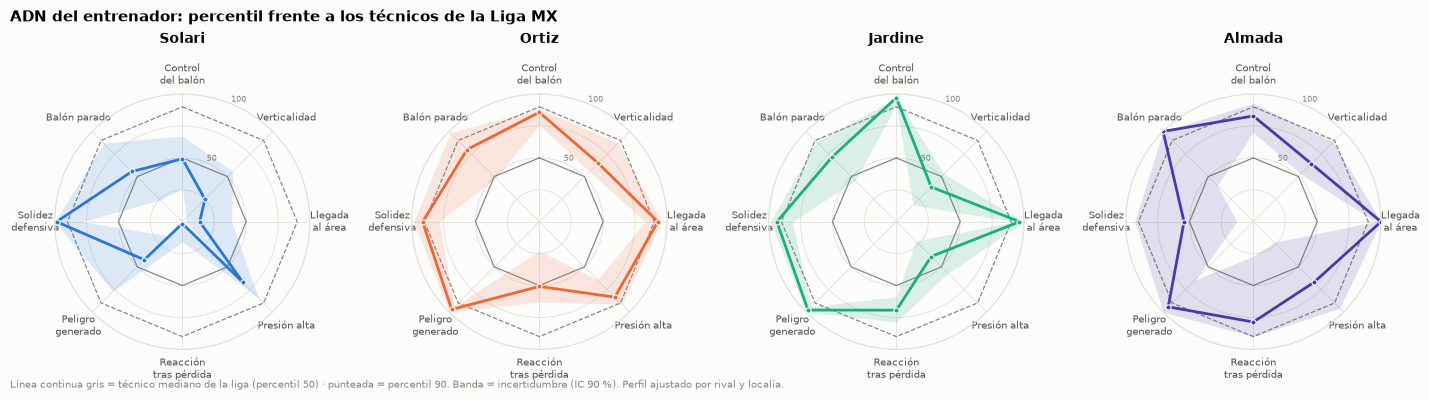

In [5]:
fig = V.fig_radars({f"{k}": pct.loc[k] for k in AMC}, cis)
save(fig, "adn_america")

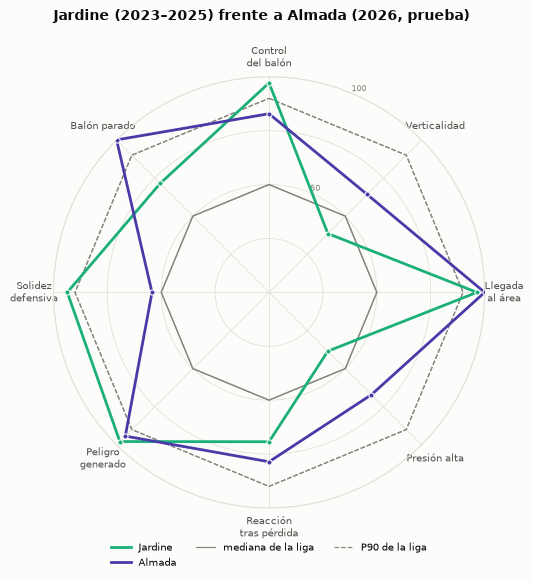

In [6]:
fig = V.fig_radar_compare({"Jardine": pct.loc["Jardine"], "Almada": pct.loc["Almada"]},
                          "Jardine (2023–2025) frente a Almada (2026, prueba)")
save(fig, "adn_jardine_almada")

## 3. Identidad del club frente a identidad del técnico (H2)

¿Qué rasgos se mantienen sin importar quién dirige (identidad del club) y cuáles cambian con el técnico? Se mide
con la **proporción de la variación entre partidos del América que se explica por el técnico** (η²): un η² bajo significa que el
rasgo es del club y uno alto que es del técnico.

In [7]:
d = ma[(ma.team_name == AM) & ma.manager.isin([AMC[k] for k in ["Solari", "Ortiz", "Jardine"]]) & (ma.split == "train")]
eta = {}
for a in C.AXES:
    x = d[f"adj__{a}"]; g = d.groupby("manager")[f"adj__{a}"]
    eta[a] = (g.size() * (g.mean() - x.mean()) ** 2).sum() / ((x - x.mean()) ** 2).sum()
ident = pd.DataFrame({"η² (técnico)": pd.Series(eta)}).sort_values("η² (técnico)")
ident["lectura"] = np.where(ident["η² (técnico)"] < 0.03, "identidad del club", np.where(ident["η² (técnico)"] < 0.10, "mixto", "identidad del técnico"))
keep(ident, "identity_eta")

,η² (técnico),lectura
Balón parado,0.00,identidad del club
Solidez defensiva,0.00,identidad del club
Verticalidad,0.04,mixto
Presión alta,0.05,mixto
Peligro generado,0.05,mixto
Reacción tras pérdida,0.06,mixto
Llegada al área,0.14,identidad del técnico
Control del balón,0.15,identidad del técnico


## 4. Consistencia: ¿identidad clara o camaleón? (5.2)

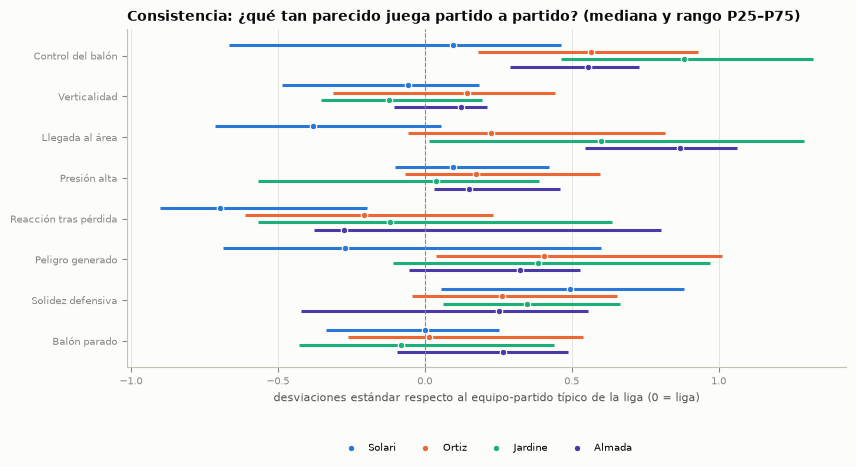

,Control del balón,Verticalidad,Llegada al área,Presión alta,Reacción tras pérdida,Peligro generado,Solidez defensiva,Balón parado
Solari,1.13,0.67,0.77,0.52,0.70,1.29,0.83,0.59
Ortiz,0.75,0.76,0.88,0.67,0.85,0.98,0.70,0.80
Jardine,0.86,0.55,1.28,0.95,1.21,1.08,0.60,0.87
Almada,0.44,0.31,0.52,0.43,1.18,0.58,0.97,0.58


In [8]:
cons = {k: C.consistency(ma, r) for k, r in rows_am.items()}
save(V.fig_consistency(cons), "consistencia")
keep(pd.DataFrame({k: c.iqr for k, c in cons.items()}).T, "consistency_iqr")

## 5. Ajuste al contexto: localía y fuerza del rival (5.2, H3)

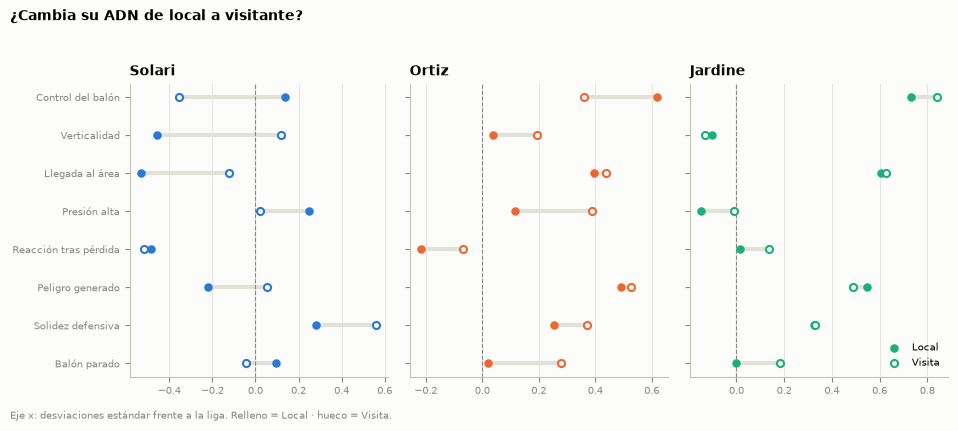

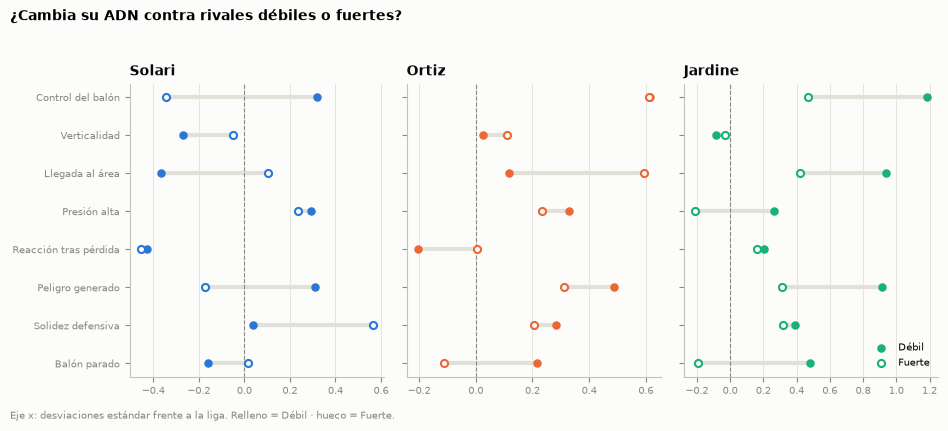

,Control del balón,Verticalidad,Llegada al área,Presión alta,Reacción tras pérdida,Peligro generado,Solidez defensiva,Balón parado,ajuste total (suma |Δ|)
Solari,-0.66,0.22,0.47,-0.05,-0.02,-0.48,0.52,0.18,2.62
Ortiz,-0.00,0.09,0.48,-0.09,0.21,-0.18,-0.08,-0.33,1.45
Jardine,-0.72,0.06,-0.51,-0.48,-0.04,-0.60,-0.07,-0.68,3.15


In [9]:
home = {k: C.context_profile(ma, r, "is_home") for k, r in rows_am.items() if k != "Almada"}
save(V.fig_context(home, "Local", "Visita", "¿Cambia su ADN de local a visitante?"), "contexto_localia")
riv = {k: C.context_profile(ma, r, "rival") for k, r in rows_am.items() if k != "Almada"}
save(V.fig_context(riv, "Débil", "Fuerte", "¿Cambia su ADN contra rivales débiles o fuertes?"), "contexto_rival")
adapt = pd.DataFrame({k: (c.loc["Fuerte"] - c.loc["Débil"]) for k, c in riv.items()}).T
adapt["ajuste total (suma |Δ|)"] = adapt.abs().sum(axis=1)
keep(adapt.round(2), "rival_adaptation")

## 6. Evolución torneo a torneo

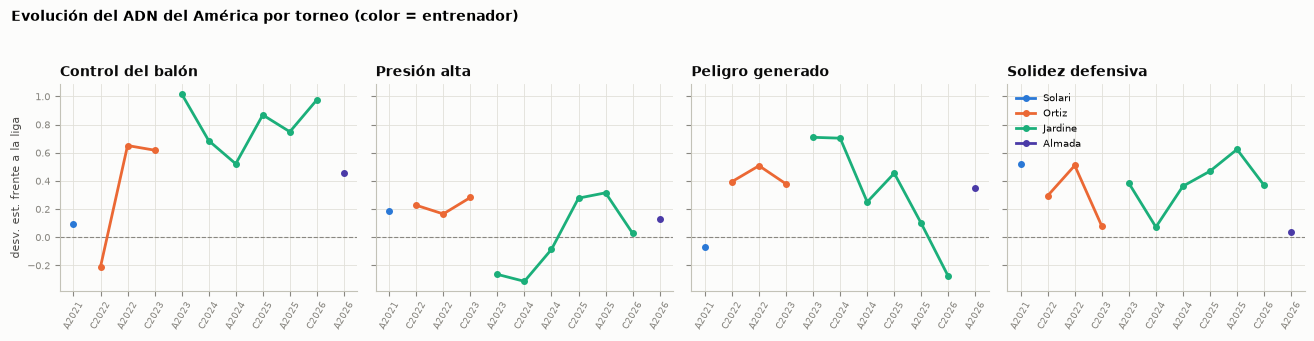

,Control del balón,Verticalidad,Llegada al área,Presión alta,Reacción tras pérdida,Peligro generado,Solidez defensiva,Balón parado,entrenador,partidos
torneo,,,,,,,,,,
Apertura 2021,0.09,-0.22,-0.42,0.18,-0.44,-0.07,0.52,0.01,Solari,19
Clausura 2022,-0.21,0.21,-0.02,0.23,-0.30,0.40,0.30,0.22,"Solari, Ortiz",21
Apertura 2022,0.65,0.04,0.56,0.17,-0.36,0.51,0.51,0.03,Ortiz,21
Clausura 2023,0.62,0.02,0.49,0.28,0.05,0.38,0.08,0.18,Ortiz,21
Apertura 2023,1.02,-0.36,0.68,-0.26,-0.32,0.71,0.38,0.15,Jardine,23
Clausura 2024,0.69,-0.05,0.48,-0.31,-0.37,0.70,0.07,-0.00,Jardine,23
Apertura 2024,0.52,-0.07,0.43,-0.09,0.48,0.25,0.36,0.03,Jardine,24
Clausura 2025,0.87,0.02,0.79,0.28,0.58,0.46,0.47,0.29,"Cervantes, Jardine",23
Apertura 2025,0.75,-0.13,0.43,0.32,0.66,0.10,0.62,0.19,Jardine,19


In [10]:
ev = C.evolution(ma)
save(V.fig_evolution(ev, ["Control del balón", "Presión alta", "Peligro generado", "Solidez defensiva"]), "evolucion")
keep(ev.round(2), "evolution")

## 7. El mapa de técnicos de la Liga MX

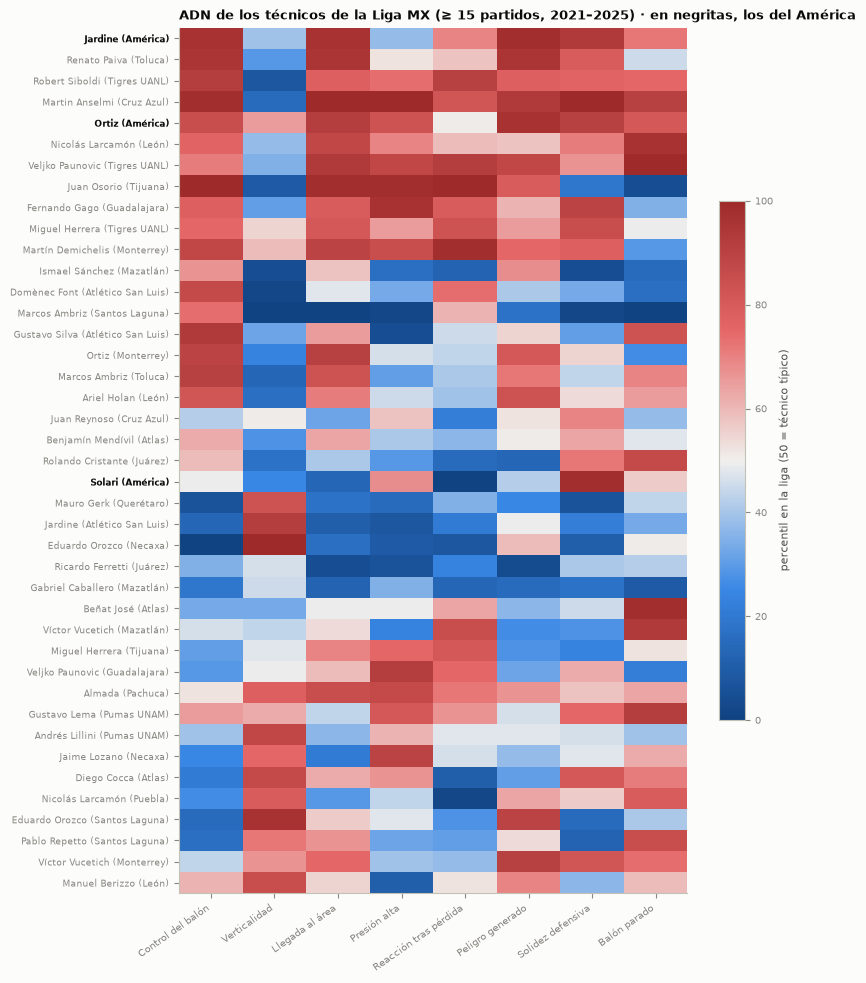

In [11]:
ref_pct = C.to_percentile(ref, ref)
hl = [i for i in ref.index if i.endswith("América")]
save(V.fig_league_heatmap(ref_pct, hl), "liga_heatmap")

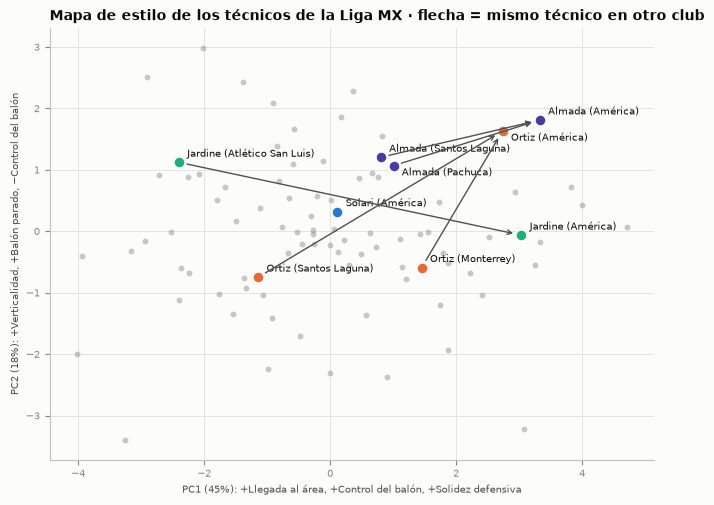

Técnicos del América que también dirigieron otro club: ['Jardine (Atlético San Luis) → América', 'Ortiz (Monterrey) → América', 'Ortiz (Santos Laguna) → América', 'Almada (Pachuca) → América', 'Almada (Santos Laguna) → América']


In [12]:
allp = C.coach_profiles(ma, period=None)  # todos los partidos (incluye 2025-2026) para ver trayectorias
am_all = C.coach_profiles(ma, period=None, min_matches=5)
allp = pd.concat([allp, am_all[am_all.team == AM]]).loc[lambda x: ~x.index.duplicated()]  # Almada-América (9 partidos)
coach_of = {i: C.short(m) for i, m in allp.manager.items()}
hl_map = {i: coach_of[i] for i in allp.index if allp.loc[i, "manager"] in AMC.values()}
movers = allp.groupby("manager").filter(lambda g: len(g) > 1 and (g.team == AM).any())
moves = []
for m, g in movers.groupby("manager"):
    am_i = g[g.team == AM].index[0]
    moves += [(i, am_i) for i in g.index if i != am_i]
fig, Z = V.fig_style_map(allp, hl_map, moves)
save(fig, "liga_mapa_estilo")
print("Técnicos del América que también dirigieron otro club:", [C.label(a) + " → América" for a, _ in moves])

## 8. ¿A quién se parece cada técnico? Índice de Encaje con la identidad del América (H10)

El **ADN histórico del América** es el promedio de sus partidos en la ventana oficial, con todos sus técnicos. El
**Índice de Encaje** (0–100) ubica a cada técnico-club de la liga según qué tan cerca está de esa identidad: 100 es el
más parecido.

In [13]:
identity = C.club_identity(ma)
fit = C.fit_index(ref, identity)
fit["técnico"] = [C.label(i) for i in fit.index]
keep(fit.head(15).set_index("técnico")[["indice_encaje", "distancia", "partidos"]], "fit_top15")
sim = pd.concat({k: C.similar_coaches(ref, i, 3).assign(similar=lambda d: [C.label(x) for x in d.index]).reset_index(drop=True)
                 for k, i in {"Jardine": "André Soares Jardine · América", "Ortiz": "Fernando Ortiz · América",
                              "Solari": "Santiago Hernán Solari Poggio · América"}.items()})
keep(sim[["similar", "distancia", "partidos"]], "similar")

,indice_encaje,distancia,partidos
técnico,,,
Ortiz (América),98.57,1.09,55
Jardine (América),97.14,1.14,91
Renato Paiva (Toluca),95.71,1.32,38
Víctor Vucetich (Monterrey),94.29,1.99,54
Ariel Holan (León),92.86,2.00,38
Ortiz (Monterrey),91.43,2.05,44
Nicolás Larcamón (León),90.00,2.07,39
Miguel Herrera (Tigres UANL),88.57,2.08,62
Vicente Sánchez (Cruz Azul),87.14,2.23,18


similar  distancia  partidos
Jardine 0        Renato Paiva (Toluca)       1.18        38
        1              Ortiz (América)       1.85        55
        2            Ortiz (Monterrey)       2.29        44
Ortiz   0            Jardine (América)       1.85        91
        1        Renato Paiva (Toluca)       2.02        38
        2  Víctor Vucetich (Monterrey)       2.17        54
Solari  0   Rolando Cristante (Toluca)       1.30        18
        1     Juan Reynoso (Cruz Azul)       1.54        38
        2  Javier Onaindía (Monterrey)       1.86        26

## 9. Validación: ¿el ADN reconoce a un técnico en partidos que nunca vio? (H9)

Se entrena un clasificador (regresión logística multinomial) con los 8 rasgos **por partido**, usando toda la liga en
la ventana oficial. La etiqueta es el **técnico**, no el equipo, y hay 31 técnicos con 30 partidos o más. Luego se le
pide adivinar quién dirigió cada partido de **validación (Apertura 2025)** y **prueba (2026)**.

La prueba más exigente es **Almada en el América**: el modelo nunca lo vio dirigir al América, solo a Pachuca. Si lo
reconoce, el estilo sigue al técnico y no a la plantilla.

In [14]:
clf, cols = C.coach_classifier(ma)
rk = C.rank_of_true_coach(clf, cols, ma)
acc = pd.DataFrame({s: C.topk_accuracy(rk[rk.split == s]) for s in ["val", "test"]}).T
keep(acc, "classifier_topk")
am_rk = rk[(rk.team_name == AM) & (rk.split != "train")]
keep(am_rk.groupby(["manager", "split"]).agg(partidos=("rank_real", "size"), posicion_mediana=("rank_real", "median"),
     en_top3=("rank_real", lambda s: (s <= 3).mean() * 100)).rename(index=C.short, level=0), "classifier_america")

,top-1,top-3,top-5,partidos,azar top-1
val,0.05,0.11,0.22,194.00,0.03
test,0.10,0.19,0.35,155.00,0.03


partidos  posicion_mediana  en_top3
manager split                                     
Jardine test         19              3.00    52.63
        val          19              2.00    52.63
Almada  test          9              2.00    66.67

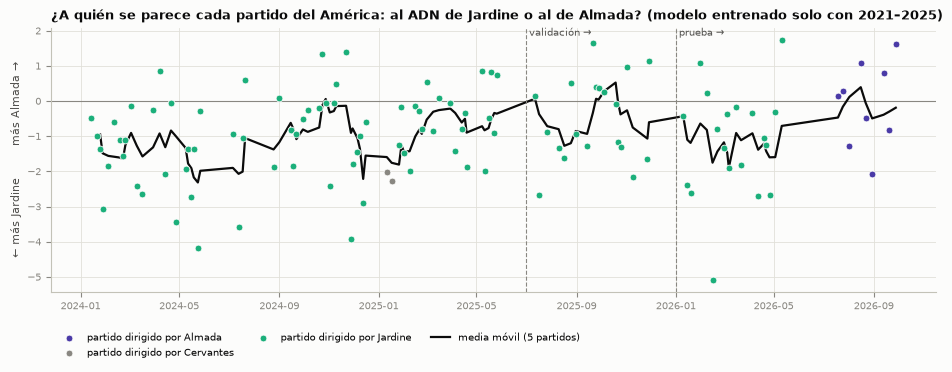

partidos  logodds_mediana  pct_mas_almada
coach_short split                                           
Almada      test          9             0.14           55.56
Cervantes   train         2            -2.14            0.00
Jardine     test         19            -1.05           15.79
            train        68            -0.92           16.18
            val          19            -0.88           42.11

In [15]:
rows = (ma.team_name == AM) & (ma.match_date >= "2024-01-01")
d = ma[rows].dropna(subset=cols)
val = d[["match_date", "manager", "split"]].assign(
    logodds=C.coach_logodds(clf, cols, d, AMC["Almada"], AMC["Jardine"]),
    coach_short=lambda x: x.manager.map(C.short)).sort_values("match_date")
save(V.fig_coach_change(val, "Almada", "Jardine"), "cambio_tecnico")
keep(val.groupby(["coach_short", "split"]).agg(partidos=("logodds", "size"), logodds_mediana=("logodds", "median"),
     pct_mas_almada=("logodds", lambda s: (s > 0).mean() * 100)), "coach_change")

**Lectura.** Partido a partido la señal es ruidosa: un solo partido depende mucho del rival y del marcador. Pero en
promedio los partidos de 2026 se desplazan del ADN de Jardine hacia el de Almada. Además, el clasificador pone a Almada
entre los técnicos más probables sin haberlo visto nunca en el América. **El estilo sigue al técnico, no a la
plantilla**: el ADN construido con su etapa en Pachuca sirve para anticipar cómo jugará en otro club. Esto es
justo lo que necesita el club para evaluar candidatos.

## 10. Valor para el club

**Dato: la rotación de técnicos en la Liga MX (ventana oficial).** Cada cambio de técnico es una decisión cara; el
ADN sirve para tomarla mejor.

In [16]:
st = B.coach_stints(tml)
keep(B.turnover_summary(st).to_frame("valor"), "turnover")

,valor
periodos de entrenador,122.00
equipos,18.00
cambios de técnico,104.00
cambios por torneo (liga),13.00
partidos por periodo (mediana),21.00
% de periodos de menos de 2 torneos,69.67


**ROI por escenarios.** Los montos son **supuestos explícitos** que el club debe validar: no hay cifras públicas
verificadas de sus costos. Por eso se muestran tres escenarios y un análisis de sensibilidad. El beneficio tiene dos
fuentes: (1) reducir la probabilidad de una contratación fallida y (2) ahorrar horas de análisis con la ficha automática.

In [17]:
keep(pd.DataFrame(B.SCENARIOS, index=["Conservador", "Base", "Optimista"]).T.assign(
    supuesto=lambda d: d.index.map(B.ASSUMPTIONS_TEXT)), "roi_assumptions")
keep(B.scenario_table(), "roi_scenarios")
keep(B.sensitivity(), "roi_sensitivity")

,Conservador,Base,Optimista,supuesto
costo_cambio_tecnico,"15,000,000.00","30,000,000.00","50,000,000.00",Costo de cambiar de técnico antes de tiempo: i...
prob_cambio_fallido,0.30,0.40,0.50,Probabilidad de que una contratación termine a...
reduccion_error,0.05,0.10,0.20,Reducción relativa de esa probabilidad al eleg...
decisiones_por_anio,0.50,1.00,1.00,Evaluaciones de técnico por año (contratación ...
horas_ahorradas_partido,2.00,4.00,6.00,Horas de analista ahorradas por partido gracia...
partidos_por_anio,40.00,45.00,50.00,Partidos analizados por año (propios y de riva...
costo_hora_analista,400.00,600.00,800.00,Costo por hora de un analista.
costo_anual_herramienta,"400,000.00","300,000.00","200,000.00",Costo anual de mantener la herramienta (sin li...


,ahorro por mejores decisiones de técnico,ahorro en horas de análisis,beneficio anual,costo anual,ROI,punto de equilibrio (reducción de error)
escenario,,,,,,
Conservador,"112,500.00",32000,"144,500.00","400,000.00",-0.64,0.16
Base,"1,200,000.00",108000,"1,308,000.00","300,000.00",3.36,0.02
Optimista,"5,000,000.00",240000,"5,240,000.00","200,000.00",25.20,0.00


,10 M,20 M,30 M,50 M
reduccion_error \ costo_cambio_tecnico,,,,
0%,-0.64,-0.64,-0.64,-0.64
5%,0.03,0.69,1.36,2.69
10%,0.69,2.03,3.36,6.03
15%,1.36,3.36,5.36,9.36
20%,2.03,4.69,7.36,12.69


**Escalabilidad.** Todo lo anterior se calculó para los 106 técnicos de la Liga MX con las mismas funciones. Cambiar
de liga (por ejemplo, a la Liga MX Femenil u otra competición con datos StatsBomb) es cambiar `COMPETITION_ID`.

**Activación.**
- Uso interno: ficha "ADN" previa a cada partido con el ADN del técnico rival, y tablero de seguimiento del técnico propio.
- Afición: tarjeta "ADN del partido" (solo agregados) para redes.

## 11. Veredicto de las hipótesis del EDA (con la partición oficial)

In [18]:
am3 = am_rk.groupby("manager").rank_real.median()
ver = pd.DataFrame([
    ("H1", "Cada técnico tiene un ADN distinguible",
     f"Top-5 en prueba {acc.loc['test','top-5']:.0%} frente a {5*acc.loc['test','azar top-1']:.0%} por azar; perfiles del América separados en presión y control"),
    ("H2", "Identidad del club frente a la del técnico",
     "Rasgos de club: " + ", ".join(ident[ident['lectura']=='identidad del club'].index) + " · del técnico: " + ", ".join(ident[ident['lectura']=='identidad del técnico'].index)),
    ("H3", "Jardine se adapta al rival más que Solari y Ortiz",
     "Ajuste total fuerte − débil: " + ", ".join(f"{k} {v:.2f}" for k, v in adapt['ajuste total (suma |Δ|)'].items())),
    ("H9", "El ADN detecta un técnico que nunca vio",
     f"Almada en el América: posición mediana {am3.get(AMC['Almada'], np.nan):.0f} de {len(clf.classes_)} técnicos"),
    ("H10", "El Índice de Encaje ordena a los técnicos de la liga", "Top 3: " + ", ".join(fit['técnico'].head(3))),
], columns=["H", "hipótesis", "evidencia"]).set_index("H")
keep(ver, "hypotheses")

,hipótesis,evidencia
H,,
H1,Cada técnico tiene un ADN distinguible,Top-5 en prueba 35% frente a 16% por azar; per...
H2,Identidad del club frente a la del técnico,"Rasgos de club: Balón parado, Solidez defensiv..."
H3,Jardine se adapta al rival más que Solari y Ortiz,"Ajuste total fuerte − débil: Solari 2.62, Orti..."
H9,El ADN detecta un técnico que nunca vio,Almada en el América: posición mediana 2 de 31...
H10,El Índice de Encaje ordena a los técnicos de l...,"Top 3: Ortiz (América), Jardine (América), Ren..."
